# Algorithm 2 Sample construction from VQ

In [ ]:
!git clone https://github.com/deepseek-ai/Janus.git

Cloning into 'Janus'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 121 (delta 58), reused 38 (delta 38), pack-reused 37 (from 1)
Receiving objects: 100% (121/121), 7.18 MiB | 16.13 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [ ]:
cd Janus/

/content/Janus


In [ ]:
pip install -e .

Obtaining file:///content/Janus
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for janus (pyproject.toml) ... done
  Created wheel for janus: filename=janus-1.0.0-0.editable-py3-none-any.whl size=15973 sha256=8f86df8a2be511c893a7333e87bdf058218b5720b64fa7e0c807efebb68f55a4
  Stored in directory: /tmp/pip-ephem-wheel-cache-v4_pkgc8/wheels/23/a7/3b/9141860486eeb74e2160152b477f84dbf4650666778faa4323
Successfully built janus


In [ ]:
!pip install transformers==4.49.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 6.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 658.2 kB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
from transformers import AutoModelForCausalLM
from janus.models import MultiModalityCausalLM, VLChatProcessor
from janus.utils.io import load_pil_images

Python version is above 3.10, patching the collections module.


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:594: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(


In [ ]:
# specify the path to the model
model_path = "deepseek-ai/Janus-Pro-1B"
vl_chat_processor: VLChatProcessor = VLChatProcessor.from_pretrained(model_path)
tokenizer = vl_chat_processor.tokenizer

vl_gpt: MultiModalityCausalLM = AutoModelForCausalLM.from_pretrained(
    model_path, trust_remote_code=True
)
vl_gpt = vl_gpt.to(torch.bfloat16).cuda().eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply

In [ ]:
import torch
from transformers import AutoModelForCausalLM
from janus.models import MultiModalityCausalLM, VLChatProcessor

model_path = "deepseek-ai/Janus-Pro-1B"

# load the processor
vl_chat_processor: VLChatProcessor = VLChatProcessor.from_pretrained(model_path)
tokenizer = vl_chat_processor.tokenizer

# load the model with device_map
# Using device_map="cuda" to automatically handle cuda transfer
vl_gpt: MultiModalityCausalLM = AutoModelForCausalLM.from_pretrained(
    model_path,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="cuda"
)

vl_gpt.eval()

Some kwargs in processor config are unused and will not have any effect: add_special_token, image_tag, mask_prompt, sft_format, ignore_id, num_image_tokens. 


MultiModalityCausalLM(
  (vision_model): CLIPVisionTower(
    (vision_tower): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Identity()
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in

## Pre-processing

Janus model requirement
* `img_size: 378 x 378`
* center crop image with size 378

In [ ]:
from PIL import Image
import torchvision.transforms as T

def preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")

    # center crop and resize to 378x378 as per Janus
    transform = T.Compose([
        T.Resize(378, interpolation=T.InterpolationMode.LANCZOS),
        T.CenterCrop(378),
        T.ToTensor(),
    ])
    return transform(img).unsqueeze(0).to(torch.bfloat16).cuda()

# Load your image
pixel_values = preprocess_image("/content/ID_0000.jpg")

In [ ]:
pixel_values

tensor([[[[0.6211, 0.7773, 0.7773,  ..., 0.7227, 0.7461, 0.7383],
          [0.5508, 0.7461, 0.7695,  ..., 0.7266, 0.7500, 0.7148],
          [0.6133, 0.7578, 0.7266,  ..., 0.7070, 0.7188, 0.7344],
          ...,
          [0.4785, 0.6133, 0.6523,  ..., 0.3379, 0.3887, 0.4043],
          [0.5117, 0.6328, 0.5898,  ..., 0.3340, 0.3770, 0.3965],
          [0.4785, 0.6289, 0.5508,  ..., 0.3574, 0.3340, 0.3613]],

         [[0.4668, 0.6250, 0.6211,  ..., 0.7695, 0.7891, 0.7812],
          [0.4004, 0.5938, 0.6172,  ..., 0.7773, 0.8008, 0.7656],
          [0.4590, 0.6055, 0.5703,  ..., 0.7617, 0.7734, 0.7891],
          ...,
          [0.2559, 0.3887, 0.4316,  ..., 0.1650, 0.2158, 0.2314],
          [0.2910, 0.4160, 0.3809,  ..., 0.1572, 0.2002, 0.2197],
          [0.2559, 0.4121, 0.3379,  ..., 0.1807, 0.1572, 0.1846]],

         [[0.4004, 0.5312, 0.4902,  ..., 0.7734, 0.7969, 0.7891],
          [0.3301, 0.4980, 0.4863,  ..., 0.7812, 0.8047, 0.7695],
          [0.3926, 0.5117, 0.4395,  ..., 0

## Contamination

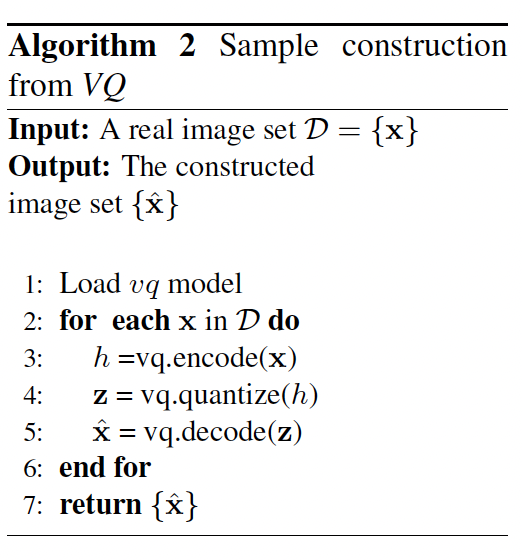


In [ ]:
@torch.no_grad()
def reconstruct_image(model, pixel_values):
    # encode: extracting the latent 'h'
    # return output type tuple in Janus codebase
    encoded_output = model.gen_vision_model.encode(pixel_values)
    h = encoded_output[0] if isinstance(encoded_output, tuple) else encoded_output

    # quantize: converting 'h' to discrete tokens 'z'
    # next-token auto-regression, where tokens are predicted sequentially
    quant_output = model.gen_vision_model.quantize(h)
    z = quant_output[0] if isinstance(quant_output, tuple) else quant_output

    # decode: converting discrete tokens back to pixels
    reconstructed = model.gen_vision_model.decode(z)

    # post-process for saving
    out = reconstructed.squeeze(0).cpu().float().clamp(0, 1)
    return T.ToPILImage()(out)

In [ ]:
# Load your image
pixel_values = preprocess_image("/content/ID_0001.jpg")
# Run the reconstruction
vq_image = reconstruct_image(vl_gpt, pixel_values)
vq_image.save("janus_reconstructed.png")

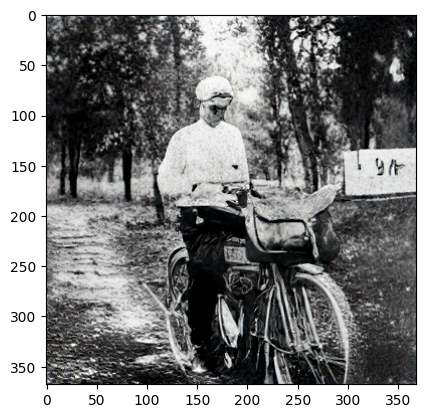

In [ ]:
# plt.imshow(pixel_values)
plt.imshow(vq_image)

## Constructing all images

In [ ]:
real_dir = "/content/real"
fake_dir = "/content/fake_vq"
# os.makedirs(fake_dir, exist_ok=True)

In [ ]:
import os
real_images = sorted([f for f in os.listdir(real_dir) if f.endswith('.jpg')])

In [ ]:
from tqdm import tqdm

print(f"Constructing {len(real_images)} images...")

for filename in tqdm(real_images):
    try:
        # load image
        img_path = os.path.join(real_dir, filename)
        # real_img = Image.open(img_path).convert("RGB")

        # pre-process the image
        pixel_values = preprocess_image(img_path)

        # construct image
        vq_image = reconstruct_image(vl_gpt, pixel_values)

        # Save
        vq_image.save(os.path.join(fake_dir, f"vq_{filename}"))

    except Exception as e:
        print(f"Skipping {filename} due to error: {e}")

print("Dataset construction complete.")

Constructing 1000 images...


100%|██████████| 1000/1000 [09:06<00:00,  1.83it/s]

Dataset construction complete.


## Loading the real images

In [ ]:
!unzip /content/my_output_folder.zip

Archive:  /content/my_output_folder.zip
  inflating: ID_0256.jpg             
  inflating: ID_0718.jpg             
  inflating: ID_0300.jpg             
  inflating: ID_0143.jpg             
  inflating: ID_0316.jpg             
  inflating: ID_0028.jpg             
  inflating: ID_0442.jpg             
  inflating: ID_0081.jpg             
  inflating: ID_0332.jpg             
  inflating: ID_0838.jpg             
  inflating: ID_0107.jpg             
  inflating: ID_0253.jpg             
  inflating: ID_0560.jpg             
  inflating: ID_0527.jpg             
  inflating: ID_0255.jpg             
  inflating: ID_0138.jpg             
  inflating: ID_0118.jpg             
  inflating: ID_0215.jpg             
  inflating: ID_0899.jpg             
  inflating: ID_0195.jpg             
  inflating: ID_0305.jpg             
  inflating: ID_0445.jpg             
  inflating: ID_0677.jpg             
  inflating: ID_0524.jpg             
  inflating: ID_0353.jpg             
  inflatin

In [ ]:
!mkdir real

In [ ]:
cd real

/content/real


In [ ]:
pwd

'/content/real'

In [ ]:
!unzip /content/real_images.zip

Archive:  /content/real_images.zip
  inflating: ID_0256.jpg             
  inflating: ID_0718.jpg             
  inflating: ID_0300.jpg             
  inflating: ID_0143.jpg             
  inflating: ID_0316.jpg             
  inflating: ID_0028.jpg             
  inflating: ID_0442.jpg             
  inflating: ID_0081.jpg             
  inflating: ID_0332.jpg             
  inflating: ID_0838.jpg             
  inflating: ID_0107.jpg             
  inflating: ID_0253.jpg             
  inflating: ID_0560.jpg             
  inflating: ID_0527.jpg             
  inflating: ID_0255.jpg             
  inflating: ID_0138.jpg             
  inflating: ID_0118.jpg             
  inflating: ID_0215.jpg             
  inflating: ID_0899.jpg             
  inflating: ID_0195.jpg             
  inflating: ID_0305.jpg             
  inflating: ID_0445.jpg             
  inflating: ID_0677.jpg             
  inflating: ID_0524.jpg             
  inflating: ID_0353.jpg             
  inflating: ID

## Saving the images

In [ ]:
!zip -r /content/file.zip /content/fake_vq

  adding: content/fake_vq/ (stored 0%)
  adding: content/fake_vq/vq_ID_0546.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0141.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0827.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0037.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0698.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0183.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0302.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0786.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0384.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0358.jpg (deflated 0%)
  adding: content/fake_vq/vq_ID_0813.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0889.jpg (deflated 2%)
  adding: content/fake_vq/vq_ID_0182.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0578.jpg (deflated 0%)
  adding: content/fake_vq/vq_ID_0635.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0952.jpg (deflated 1%)
  adding: content/fake_vq/vq_ID_0520.jpg (deflated 0%)
  adding: content/fake_vq/

In [ ]:
from google.colab import files
files.download("/content/file.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Algorithm 3 Sample construction from Diffusion

**Running this model in Kaggle notebook for gpu reasons**
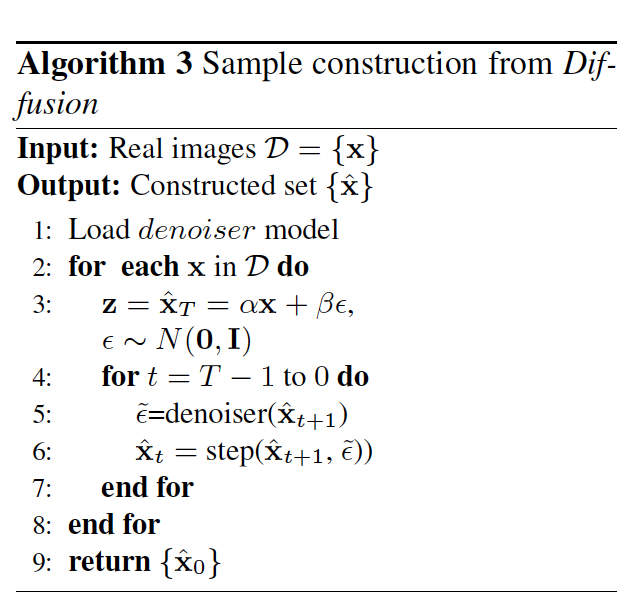

**Model trained in Kaggle notebook for GPU reasons**

In [ ]:
# PixelFlow import
import sys
!git clone https://github.com/ShoufaChen/PixelFlow
# sys.path.append('/kaggle/working/PixelFlow')

Cloning into 'PixelFlow'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 36 (delta 10), reused 13 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 48.84 KiB | 926.00 KiB/s, done.
Resolving deltas: 100% (10/10), done.


In [ ]:
# !pip3 install -r /content/PixelFlow/requirements.txt

In [ ]:
# # 1. Update sympy to fix the Torch 3.12 conflict
# !pip install --upgrade sympy --quiet

# # 2. Reinstall compatible versions of the vision stack
# !pip install --upgrade torchvision torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59

In [ ]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


In [ ]:
import torch
import requests
from PIL import Image
from torchvision import transforms as T
import os

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from PixelFlow.pixelflow.model import PixelFlowModel

In [ ]:
denoiser = PixelFlowModel(num_attention_heads=16,
                          attention_head_dim=72,
                          in_channels=3,
                          out_channels=3,
                          depth=28,
                          num_classes=1000,
                          patch_size=4
                        )

checkpoint = torch.load('/content/drive/MyDrive/models/pixelflow_model.pt', map_location=DEVICE)

# Check if it's a state_dict or a wrapped checkpoint
if "state_dict" in checkpoint:
    message = denoiser.load_state_dict(checkpoint["state_dict"], strict=False)
else:
    message = denoiser.load_state_dict(checkpoint, strict=False)
print(f"Loaded weights with partial match: {message}")

denoiser.to(DEVICE)
denoiser.eval()

Starting Initialization...
Loaded weights with partial match: _IncompatibleKeys(missing_keys=['class_embedder.embedding_table.weight'], unexpected_keys=['transformer_blocks.0.norm2.weight', 'transformer_blocks.0.attn2.q_proj.weight', 'transformer_blocks.0.attn2.q_proj.bias', 'transformer_blocks.0.attn2.k_proj.weight', 'transformer_blocks.0.attn2.k_proj.bias', 'transformer_blocks.0.attn2.v_proj.weight', 'transformer_blocks.0.attn2.v_proj.bias', 'transformer_blocks.0.attn2.o_proj.weight', 'transformer_blocks.0.attn2.o_proj.bias', 'transformer_blocks.0.attn2.q_norm.weight', 'transformer_blocks.0.attn2.k_norm.weight', 'transformer_blocks.1.norm2.weight', 'transformer_blocks.1.attn2.q_proj.weight', 'transformer_blocks.1.attn2.q_proj.bias', 'transformer_blocks.1.attn2.k_proj.weight', 'transformer_blocks.1.attn2.k_proj.bias', 'transformer_blocks.1.attn2.v_proj.weight', 'transformer_blocks.1.attn2.v_proj.bias', 'transformer_blocks.1.attn2.o_proj.weight', 'transformer_blocks.1.attn2.o_proj.bias

PixelFlowModel(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1152, kernel_size=(4, 4), stride=(4, 4))
  )
  (time_proj): Timesteps()
  (timestep_embedder): TimestepEmbedding(
    (linear_1): Linear(in_features=256, out_features=1152, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1152, out_features=1152, bias=True)
  )
  (latent_size_embedder): TimestepEmbedding(
    (linear_1): Linear(in_features=256, out_features=1152, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1152, out_features=1152, bias=True)
  )
  (class_embedder): LabelEmbedding(
    (embedding_table): Embedding(1001, 1152)
  )
  (transformer_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (norm1): AdaLayerNorm(
        (silu): SiLU()
        (linear): Linear(in_features=1152, out_features=6912, bias=True)
        (norm): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      )
      (attn1): Attention(
        (q_proj): Linear(in_features=1152, out_features=1152,

In [ ]:
# hyparameters from the paper (Algorithm 3)
T_STEPS = 50        # no. of denoising iterations
STRENGTH = 0.4      # noise strength

In [ ]:
@torch.no_grad()
def algorithm_3_pixelflow(image_path, denoiser):

  # load and preprocess image
  # Using 256 based on your YAML resolution based on codebase
  raw_img = Image.open(image_path).convert("RGB").resize((256, 256))
  x_real = T.ToTensor()(raw_img).unsqueeze(0).to(DEVICE) # [1, 3, 256, 256]

  # Adding noise
  # z = alpha * x + beta * epsilon
  epsilon = torch.randn_like(x_real)

  # starting strength level at 'T'
  t_start = torch.tensor([STRENGTH]).to(DEVICE).to(torch.float16)
  x_t = (1 - t_start) * x_real + t_start * epsilon

  # denoising loop
  dt = STRENGTH / T_STEPS

  dummy_class = torch.zeros((1,), device=DEVICE, dtype=torch.long)

  res = 256
  patch_size = 4
  head_dim = denoiser.attention_head_dim


  res = 256
  patch_size = 4
  head_dim = denoiser.attention_head_dim # Should be 72 based on your YAML
  seq_len = (res // patch_size) ** 2     # 64 * 64 = 4096
  dummy_pos = torch.ones((seq_len, head_dim, 2), device=DEVICE).half()

  for i in range(T_STEPS):
    t_val = (STRENGTH - (i * dt)) * 1000
    # current time step
    curr_t = torch.tensor([STRENGTH - (i * dt)]).to(DEVICE)

    curr_latent_size = torch.tensor([256.0], device=DEVICE).half()
    class_labels = torch.zeros((1,), device=DEVICE, dtype=torch.long)

    # the denoiser predicts the 'velocity' or noise
    # PixelFlow takes input as typically takes (x, t)
    v_pred = denoiser(
        hidden_states=x_t,
        encoder_hidden_states=None,
        class_labels=class_labels,
        timestep=curr_t,
        latent_size=curr_latent_size,
        pos_embed=dummy_pos
        )

    # backward step (Euler step)
    # x_{t-dt} = x_t - v_pred * dt
    x_t = x_t - v_pred * dt

  # contaminated image
  x_hat = x_t.clamp(0, 1).cpu().squeeze(0)
  return T.ToPILImage()(x_hat)

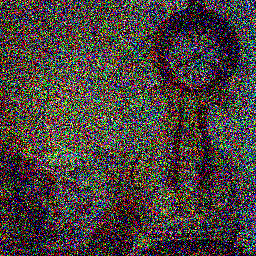

In [ ]:
algorithm_3_pixelflow("/content/real/ID_0000.jpg", denoiser=denoiser)

## model 2 with changes

In [ ]:
@torch.no_grad()
def algorithm_3_pixelflow(image_path, denoiser):

  # load and preprocess image
  # Using 256 based on your YAML resolution based on codebase
  raw_img = Image.open(image_path).convert("RGB").resize((256, 256))
  x_real = T.ToTensor()(raw_img).unsqueeze(0).to(DEVICE).half() # [1, 3, 256, 256]
  x_real = x_real * 2 - 1  # Shift [0,1] to [-1,1]

  # Adding noise
  # z = alpha * x + beta * epsilon
  epsilon = torch.randn_like(x_real)
  x_t = (1 - STRENGTH) * x_real + STRENGTH * epsilon

  # # starting strength level at 'T'
  # t_start = torch.tensor([STRENGTH]).to(DEVICE).to(torch.float16)
  # x_t = (1 - t_start) * x_real + t_start * epsilon

  # denoising loop
  dt = STRENGTH / T_STEPS

  # dummy_class = torch.zeros((1,), device=DEVICE, dtype=torch.long)

  res = 256
  patch_size = 4
  head_dim = denoiser.attention_head_dim


  res = 256
  patch_size = 4
  head_dim = denoiser.attention_head_dim # Should be 72 based on your YAML
  seq_len = (res // patch_size) ** 2     # 64 * 64 = 4096
  dummy_pos = torch.zeros((seq_len, head_dim, 2), device=DEVICE).half()

  for i in range(T_STEPS):
    t_val = (STRENGTH - (i * dt)) * 1000
    # current time step
    curr_t = torch.tensor([STRENGTH - (i * dt)]).to(DEVICE).half()

    curr_latent_size = torch.tensor([256.0], device=DEVICE).half()
    class_labels = torch.zeros((1,), device=DEVICE, dtype=torch.long)

    # the denoiser predicts the 'velocity' or noise
    # PixelFlow takes input as typically takes (x, t)
    v_pred = denoiser(
        hidden_states=x_t,
        encoder_hidden_states=None,
        class_labels=class_labels,
        timestep=curr_t,
        latent_size=curr_latent_size,
        pos_embed=dummy_pos
        )

    # backward step (Euler step)
    # x_{t-dt} = x_t - v_pred * dt
    x_t = x_t - v_pred * dt

  # contaminated image
  x_hat = (x_t + 1) / 2
  x_hat = x_hat.clamp(0, 1).cpu().float().squeeze(0)


  return T.ToPILImage()(x_hat)

In [ ]:
import matplotlib.pyplot as plt

image_2 = algorithm_3_pixelflow("/content/real/ID_0000.jpg", denoiser=denoiser)

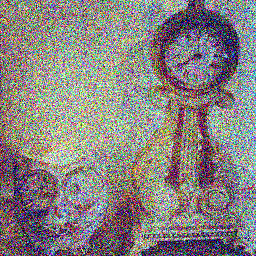

In [ ]:
image_2

## chaning hyperparameters


From
```
x_t = x_t - v_pred * dt
```
To
```
x_t = x_t + v_pred * dt
```

`STRENGTH=0.2`

In [ ]:
# hyperparameters from the paper (Algorithm 3)
T_STEPS = 50        # no. of denoising iterations
STRENGTH = 0.2      # noise strength

In [ ]:
# 1. PRE-CALCULATE CONSTANTS (Outside the loop for speed)
RES = 256
PATCH_SIZE = 4
HEAD_DIM = denoiser.attention_head_dim # 72
SEQ_LEN = (RES // PATCH_SIZE) ** 2     # 4096

# Create the dummy embedding once and keep it on the GPU
DUMMY_POS = torch.zeros((SEQ_LEN, HEAD_DIM, 2), device=DEVICE).half()
CLASS_LABELS = torch.zeros((1,), device=DEVICE, dtype=torch.long)
CURR_LATENT_SIZE = torch.tensor([float(RES)], device=DEVICE).half()

@torch.no_grad()
def algorithm_3_pixelflow(image_path, denoiser):

  # load and preprocess image
  # Using 256 based on your YAML resolution based on codebase
  raw_img = Image.open(image_path).convert("RGB").resize((256, 256))
  x_real = T.ToTensor()(raw_img).unsqueeze(0).to(DEVICE).half() # [1, 3, 256, 256]
  x_real = x_real * 2 - 1  # Shift [0,1] to [-1,1]

  # Adding noise
  # z = alpha * x + beta * epsilon
  epsilon = torch.randn_like(x_real)
  x_t = (1 - STRENGTH) * x_real + STRENGTH * epsilon

  # # starting strength level at 'T'
  # t_start = torch.tensor([STRENGTH]).to(DEVICE).to(torch.float16)
  # x_t = (1 - t_start) * x_real + t_start * epsilon

  # denoising loop
  dt = STRENGTH / T_STEPS

  for i in range(T_STEPS):
    t_val = (STRENGTH - (i * dt)) * 1000
    # current time step
    curr_t = torch.tensor([STRENGTH - (i * dt)]).to(DEVICE).half()

    # the denoiser predicts the 'velocity' or noise
    # PixelFlow takes input as typically takes (x, t)
    v_pred = denoiser(
        hidden_states=x_t,
        encoder_hidden_states=None,
        class_labels=CLASS_LABELS,
        timestep=curr_t,
        latent_size=CURR_LATENT_SIZE,
        pos_embed=DUMMY_POS
      )

    # backward step (Euler step)
    # x_{t-dt} = x_t - v_pred * dt
    x_t = x_t + v_pred * dt

  # contaminated image
  x_hat = (x_t + 1) / 2
  x_hat = x_hat.clamp(0, 1).cpu().float().squeeze(0)

  return T.ToPILImage()(x_hat)

In [ ]:
import matplotlib.pyplot as plt

image_3 = algorithm_3_pixelflow("/content/real/ID_0000.jpg", denoiser=denoiser)

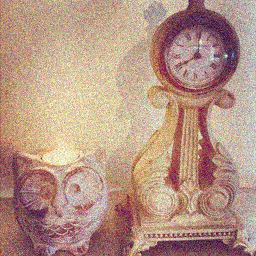

In [ ]:
image_3

## trying with 25 steps

In [ ]:
# hyperparameters from the paper (Algorithm 3)
T_STEPS = 25     # no. of denoising iterations
STRENGTH = 0.2      # noise strength

In [ ]:
# 1. PRE-CALCULATE CONSTANTS (Outside the loop for speed)
RES = 256
PATCH_SIZE = 4
HEAD_DIM = denoiser.attention_head_dim # 72
SEQ_LEN = (RES // PATCH_SIZE) ** 2     # 4096

# Create the dummy embedding once and keep it on the GPU
DUMMY_POS = torch.zeros((SEQ_LEN, HEAD_DIM, 2), device=DEVICE).half()
CLASS_LABELS = torch.zeros((1,), device=DEVICE, dtype=torch.long)
CURR_LATENT_SIZE = torch.tensor([float(RES)], device=DEVICE).half()

@torch.no_grad()
def algorithm_3_diffusion(image_path, denoiser):

  # load and preprocess image
  # Using 256 based on your YAML resolution based on codebase
  raw_img = Image.open(image_path).convert("RGB").resize((256, 256))
  x_real = T.ToTensor()(raw_img).unsqueeze(0).to(DEVICE).half() # [1, 3, 256, 256]
  x_real = x_real * 2 - 1  # Shift [0,1] to [-1,1]

  # Adding noise
  # z = alpha * x + beta * epsilon
  epsilon = torch.randn_like(x_real)
  x_t = (1 - STRENGTH) * x_real + STRENGTH * epsilon

  # # starting strength level at 'T'
  # t_start = torch.tensor([STRENGTH]).to(DEVICE).to(torch.float16)
  # x_t = (1 - t_start) * x_real + t_start * epsilon

  # denoising loop
  dt = STRENGTH / T_STEPS

  for i in range(T_STEPS):
    t_val = (STRENGTH - (i * dt)) * 1000
    # current time step
    curr_t = torch.tensor([STRENGTH - (i * dt)]).to(DEVICE).half()

    # the denoiser predicts the 'velocity' or noise
    # PixelFlow takes input as typically takes (x, t)
    v_pred = denoiser(
        hidden_states=x_t,
        encoder_hidden_states=None,
        class_labels=CLASS_LABELS,
        timestep=curr_t,
        latent_size=CURR_LATENT_SIZE,
        pos_embed=DUMMY_POS
      )

    # backward step (Euler step)
    # x_{t-dt} = x_t - v_pred * dt
    x_t = x_t + v_pred * dt

  # contaminated image
  x_hat = (x_t + 1) / 2
  x_hat = x_hat.clamp(0, 1).cpu().float().squeeze(0)

  return T.ToPILImage()(x_hat)

In [ ]:
import matplotlib.pyplot as plt

image_4 = algorithm_3_diffusion("/content/real/ID_0000.jpg", denoiser=denoiser)

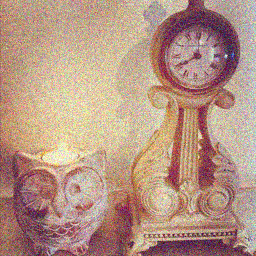

In [ ]:
image_4

## model4

In [ ]:
@torch.no_grad()
def algorithm_3_diffusion_v4(image_path, denoiser):
    # 1. LOAD IMAGE (SEC 5.1: USE CROP, NOT RESIZE)
    raw_img = Image.open(image_path).convert("RGB")

    RES = 256

    # Check if image is large enough, otherwise this sample should be skipped
    # based on "whenever the resolution allows" in Sec 5.1
    center_crop = T.CenterCrop(RES)
    cropped_img = center_crop(raw_img)

    x_real = T.ToTensor()(cropped_img).unsqueeze(0).to(DEVICE).half()
    x_real = x_real * 2 - 1  # Map to [-1, 1]

    # 2. ADD NOISE (ALG 3, LINE 3)
    # z = alpha * x + beta * epsilon. For Flow Matching: x_t = (1-t)x + t*eps
    epsilon = torch.randn_like(x_real)
    # Using STRENGTH as our starting 't'
    x_t = (1 - STRENGTH) * x_real + STRENGTH * epsilon

    # 3. DENOISING LOOP (ALG 3, LINES 4-7)
    dt = STRENGTH / T_STEPS

    for i in range(T_STEPS):
        # Calculate current t dropping from STRENGTH to 0
        t_val = STRENGTH - (i * dt)
        curr_t = torch.tensor([t_val], device=DEVICE).half()

        # ALG 3, LINE 5: Get the "Final Touch" from the denoiser
        v_pred = denoiser(
            hidden_states=x_t,
            encoder_hidden_states=None,
            class_labels=CLASS_LABELS,
            timestep=curr_t * 1000, # Most models scale t by 1000
            latent_size=CURR_LATENT_SIZE,
            pos_embed=DUMMY_POS
        )

        # ALG 3, LINE 6: Update step
        # In Flow Matching, the ODE is dx/dt = v.
        # To go from noise (t=1) to data (t=0), we move in direction -v.
        x_t = x_t - v_pred * dt

    # 4. FINAL OUTPUT
    x_hat = (x_t + 1) / 2
    x_hat = x_hat.clamp(0, 1).cpu().float().squeeze(0)

    return T.ToPILImage()(x_hat)

In [ ]:
image_5 = algorithm_3_diffusion_v4("/content/real/ID_0001.jpg", denoiser=denoiser)

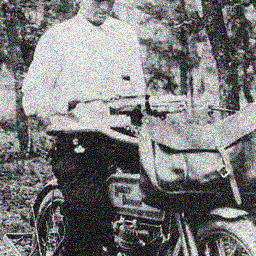

In [ ]:
image_5

## Constructing for all the images

In [ ]:
!mkdir fake_diffusion

In [ ]:
real_dir = "/content/real"
fake_dir = "/content/fake_diffusion"
# os.makedirs(fake_dir, exist_ok=True)

In [ ]:
import os
real_images = sorted([f for f in os.listdir(real_dir) if f.endswith('.jpg')])[:100]

In [ ]:
len(real_images[:100])

100

In [ ]:
from tqdm import tqdm

print(f"Constructing {len(real_images)} images...")

for filename in tqdm(real_images):
    try:
      filepath = os.path.join(real_dir, filename)

      # load and construct the image
      img = algorithm_3_diffusion_v4(image_path=filepath, denoiser=denoiser)

      # Save
      img.save(os.path.join(fake_dir, f"{filename}"))

    except Exception as e:
        print(f"Skipping {filename} due to error: {e}")

print("Dataset construction complete.")

Constructing 100 images...


 48%|████▊     | 48/100 [45:56<49:46, 57.43s/it]

In [ ]:
from torch.utils.data import Dataset, DataLoader
import os

class PixelFlowDataset(Dataset):
    def __init__(self, img_dir, res=256):
        self.img_dir = img_dir
        self.res = res
        self.file_list = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = T.Compose([
            T.Resize((res, res)),
            T.ToTensor(),
            T.Normalize([0.5], [0.5]) # Directly to [-1, 1]
        ])

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_name = self.file_list[idx]
        path = os.path.join(self.img_dir, img_name)
        img = Image.open(path).convert("RGB")
        return self.transform(img), img_name

# Use a batch size your GPU can handle (Start with 4 or 8)
BATCH_SIZE = 16
dataset = PixelFlowDataset(real_dir)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [ ]:
@torch.no_grad()
def process_batches(dataloader, denoiser, output_dir):
    # Setup constants for the batch
    res = 256
    patch_size = 4
    head_dim = denoiser.attention_head_dim
    seq_len = (res // patch_size) ** 2

    T_STEPS = 25
    STRENGTH = 0.2

    # Pre-broadcast dummy pos to match Batch Size
    # Shape: [B, Seq_Len, Head_Dim, 2] -> PixelFlow's forward handles broadcasting if we give it [Seq_Len, Head_Dim, 2]
    dummy_pos = torch.zeros((seq_len, head_dim, 2), device=DEVICE).half()
    latent_size_batch = torch.tensor([float(res)], device=DEVICE).half().repeat(BATCH_SIZE)

    for batch_imgs, filenames in tqdm(dataloader):
        curr_batch_size = batch_imgs.shape[0]
        x_real = batch_imgs.to(DEVICE).half()

        # 1. Add Noise
        epsilon = torch.randn_like(x_real)
        x_t = (1 - STRENGTH) * x_real + STRENGTH * epsilon
        dt = STRENGTH / T_STEPS

        # 2. Iterative Denoising
        for i in range(T_STEPS):
            t_val = (STRENGTH - (i * dt)) * 1000
            # Timestep must match the current batch size
            curr_t = torch.full((curr_batch_size,), t_val, device=DEVICE).half()
            # Labels for batch
            class_labels = torch.zeros((curr_batch_size,), device=DEVICE, dtype=torch.long)
            # Latent size for batch
            l_size = latent_size_batch[:curr_batch_size]

            v_pred = denoiser(
                hidden_states=x_t,
                class_labels=class_labels,
                timestep=curr_t,
                latent_size=l_size,
                pos_embed=dummy_pos
            )

            x_t = x_t + v_pred * dt

        # 3. Save the Batch
        x_hat = (x_t + 1) / 2
        x_hat = x_hat.clamp(0, 1).cpu().float()

        for j in range(curr_batch_size):
            final_img = T.ToPILImage()(x_hat[j])
            final_img.save(os.path.join(output_dir, filenames[j]))

In [ ]:
# Execute
process_batches(dataloader, denoiser, fake_dir)

  0%|          | 0/63 [14:43<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import os
from tqdm import tqdm

# 1. Setup paths
real_dir = "/content/real"
fake_dir = "/content/fake_pixelflow"
os.makedirs(fake_dir, exist_ok=True)

# 2. Get file list
# all_files = [f for f in os.listdir(real_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
all_files = sorted([f for f in os.listdir(real_dir) if f.endswith('.jpg')])
BATCH_SIZE = 16

# 1. PRE-CALCULATE CONSTANTS (Outside the loop for speed)
RES = 256
PATCH_SIZE = 4
HEAD_DIM = denoiser.attention_head_dim # 72
SEQ_LEN = (RES // PATCH_SIZE) ** 2     # 4096

# Create the dummy embedding once and keep it on the GPU
DUMMY_POS = torch.zeros((SEQ_LEN, HEAD_DIM, 2), device=DEVICE).half()
CLASS_LABELS = torch.zeros((1,), device=DEVICE, dtype=torch.long)
CURR_LATENT_SIZE = torch.tensor([float(RES)], device=DEVICE).half()


print(f"Manually batching {len(all_files)} images...")

# 3. Manual Batch Loop
for i in tqdm(range(0, len(all_files), BATCH_SIZE)):
    batch_filenames = all_files[i : i + BATCH_SIZE]
    curr_batch_len = len(batch_filenames)

    # --- Manual Preprocessing ---
    batch_tensors = []
    for fname in batch_filenames:
        img_path = os.path.join(real_dir, fname)
        raw_img = Image.open(img_path).convert("RGB").resize((256, 256))
        tensor_img = T.ToTensor()(raw_img).unsqueeze(0) * 2 - 1 # Shift to [-1, 1]
        batch_tensors.append(tensor_img)

    # Stack into [B, 3, 256, 256]
    x_real = torch.cat(batch_tensors, dim=0).to(DEVICE).half()

    # --- The PixelFlow Core ---
    epsilon = torch.randn_like(x_real)
    x_t = (1 - STRENGTH) * x_real + STRENGTH * epsilon
    dt = STRENGTH / T_STEPS

    with torch.no_grad():
        for step in range(T_STEPS):
            t_val = (STRENGTH - (step * dt)) * 1000
            curr_t = torch.full((curr_batch_len,), t_val, device=DEVICE).half()

            # Predict velocity
            v_pred = denoiser(
                hidden_states=x_t,
                class_labels=torch.zeros((curr_batch_len,), device=DEVICE, dtype=torch.long),
                timestep=curr_t,
                latent_size=torch.tensor([256.0], device=DEVICE).half().repeat(curr_batch_len),
                pos_embed=DUMMY_POS # Using the global dummy we made earlier
            )
            x_t = x_t + v_pred * dt

    # --- Save Results ---
    x_hat = ((x_t + 1) / 2).clamp(0, 1).cpu().float()
    for j in range(curr_batch_len):
        T.ToPILImage()(x_hat[j]).save(os.path.join(fake_dir, batch_filenames[j]))

print("Done!")

Manually batching 1000 images...


  0%|          | 0/63 [03:33<?, ?it/s]


KeyboardInterrupt: 